In [9]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution

In [10]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [11]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

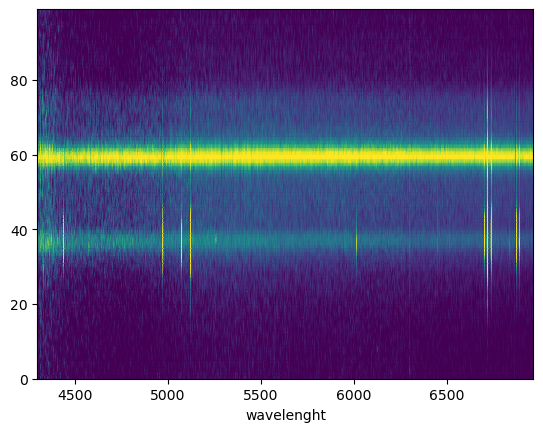

In [12]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [13]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

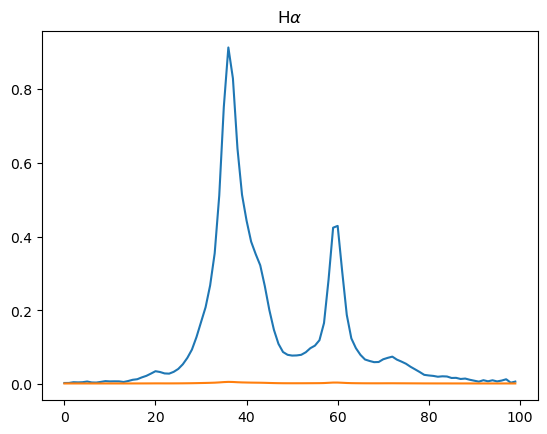

In [14]:
#Ogni punto del flusso è il risultato della media di 20 lunghezze d'onda, otteniamo l'errore con propagazione
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))/image_error_HA.shape[1]

x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [15]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss

def AIC(x, y, y_err, params): #k=number of model parameter, N=number of data points
    chi_quad = np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    return chi_quad + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1)), chi_quad

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

In [16]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 1.493348661559805
differential_evolution step 2: f(x)= 0.7134238974073212
differential_evolution step 3: f(x)= 0.7134238974073212
differential_evolution step 4: f(x)= 0.7134238974073212
differential_evolution step 5: f(x)= 0.7134238974073212
differential_evolution step 6: f(x)= 0.7134238974073212
differential_evolution step 7: f(x)= 0.7134238974073212
differential_evolution step 8: f(x)= 0.7134238974073212
differential_evolution step 9: f(x)= 0.7134238974073212
differential_evolution step 10: f(x)= 0.691183653949284
differential_evolution step 11: f(x)= 0.6746884386001728
differential_evolution step 12: f(x)= 0.6746884386001728
differential_evolution step 13: f(x)= 0.6698116409619691
differential_evolution step 14: f(x)= 0.6386244328172889
differential_evolution step 15: f(x)= 0.6386244328172889
differential_evolution step 16: f(x)= 0.6175279249134642
differential_evolution step 17: f(x)= 0.6156172321294983
differential_evolution step 18: f(x)= 0.61

47802.948531736765 47794.527479105185
Reduced chi square: 497.85966124067903


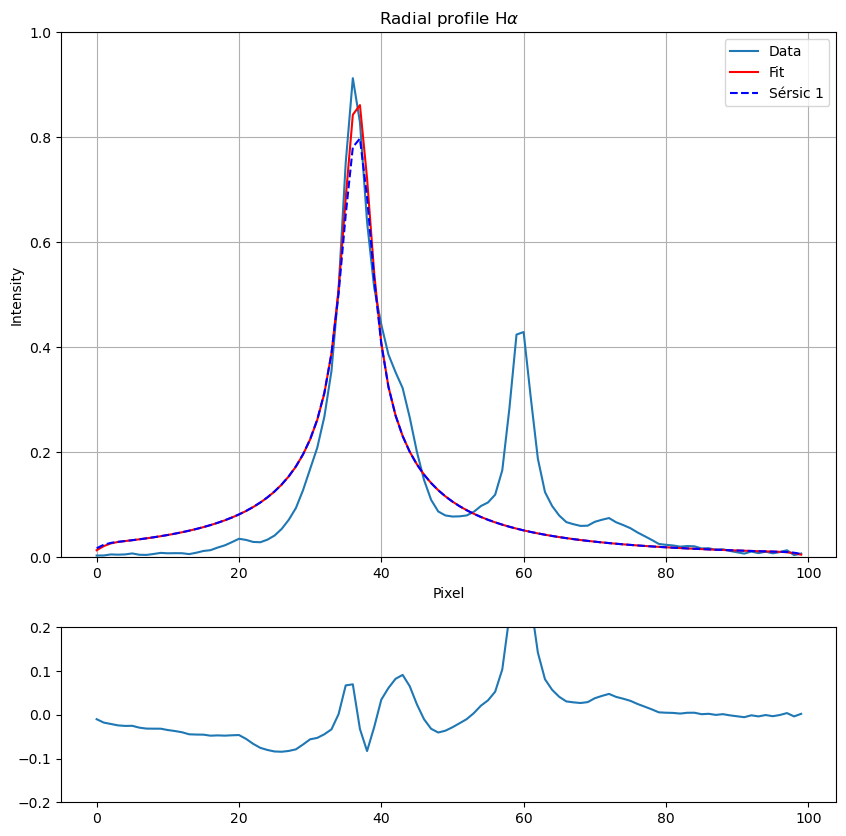

In [17]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic = np.zeros(6)
chi_quad = np.zeros(6)
red_chi = np.zeros(6)
aic[0], chi_quad[0] = (AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params1))
print(aic[0], chi_quad[0])

dof_HA = len(radial_profile_HA) - len(best_params1)
print('Reduced chi square:', chi_quad[0] / dof_HA)
red_chi[0] = chi_quad[0] / dof_HA
plt.savefig('AIC_1')

In [18]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 1.9678481224653404
differential_evolution step 2: f(x)= 1.3047069462359546
differential_evolution step 3: f(x)= 1.3047069462359546
differential_evolution step 4: f(x)= 1.011768179708269
differential_evolution step 5: f(x)= 1.011768179708269
differential_evolution step 6: f(x)= 0.9002448479775887
differential_evolution step 7: f(x)= 0.9002448479775887
differential_evolution step 8: f(x)= 0.859484382140737
differential_evolution step 9: f(x)= 0.6986440700379379
differential_evolution step 10: f(x)= 0.6986440700379379
differential_evolution step 11: f(x)= 0.6986440700379379
differential_evolution step 12: f(x)= 0.6947753957442693
differential_evolution step 13: f(x)= 0.6947753957442693
differential_evolution step 14: f(x)= 0.5732426478913625
differential_evolution step 15: f(x)= 0.5732426478913625
differential_evolution step 16: f(x)= 0.5726717980373398
differential_evolution step 17: f(x)= 0.5097594276719143
differential_evolution step 18: f(x)= 0.509

7014.46281600052 6996.880398418103
Reduced chi square: 76.05304780889243


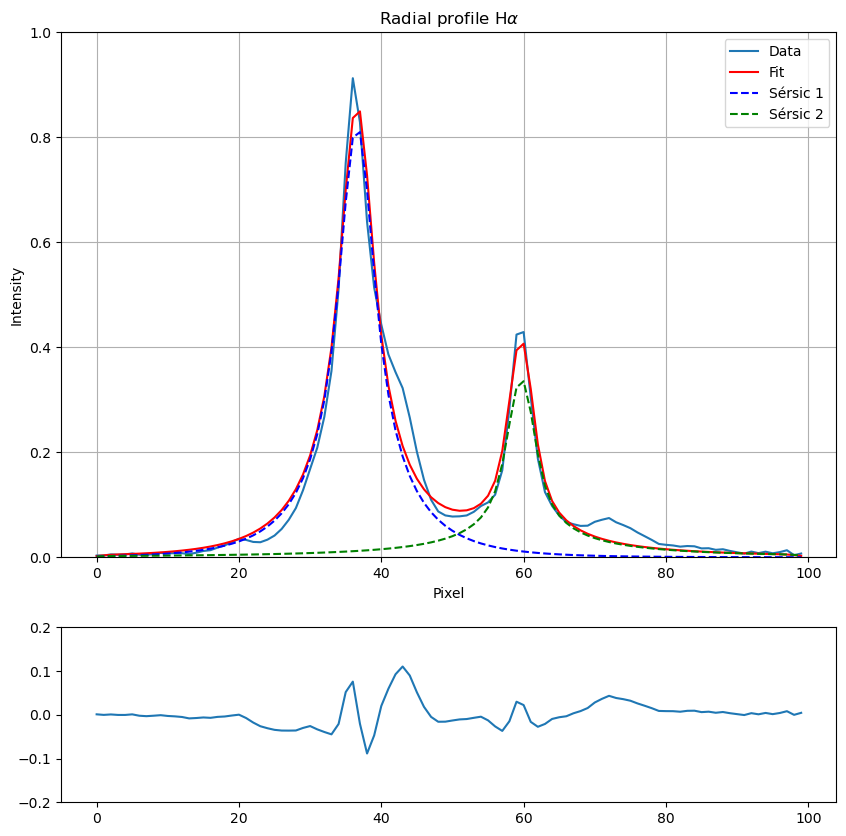

In [19]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[1], chi_quad[1] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params2)
print(aic[1], chi_quad[1])
dof_HA = len(radial_profile_HA) - len(best_params2)
print('Reduced chi square:', chi_quad[1] / dof_HA)
red_chi[1] = chi_quad[1] / dof_HA
plt.savefig('AIC_2')

In [20]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
    
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 3.0850582214796263
differential_evolution step 2: f(x)= 1.7137939464755343
differential_evolution step 3: f(x)= 1.7137939464755343
differential_evolution step 4: f(x)= 1.4769855125417404
differential_evolution step 5: f(x)= 0.6287153646874143
differential_evolution step 6: f(x)= 0.6287153646874143
differential_evolution step 7: f(x)= 0.6287153646874143
differential_evolution step 8: f(x)= 0.6287153646874143
differential_evolution step 9: f(x)= 0.6287153646874143
differential_evolution step 10: f(x)= 0.6287153646874143
differential_evolution step 11: f(x)= 0.6287153646874143
differential_evolution step 12: f(x)= 0.6287153646874143
differential_evolution step 13: f(x)= 0.6287153646874143
differential_evolution step 14: f(x)= 0.6287153646874143
differential_evolution step 15: f(x)= 0.6287153646874143
differential_evolution step 16: f(x)= 0.6287153646874143
differential_evolution step 17: f(x)= 0.6287153646874143
differential_evolution step 18: f(x)= 0.

2633.474181750889 2605.8879748543372
Reduced chi square: 29.612363350617468


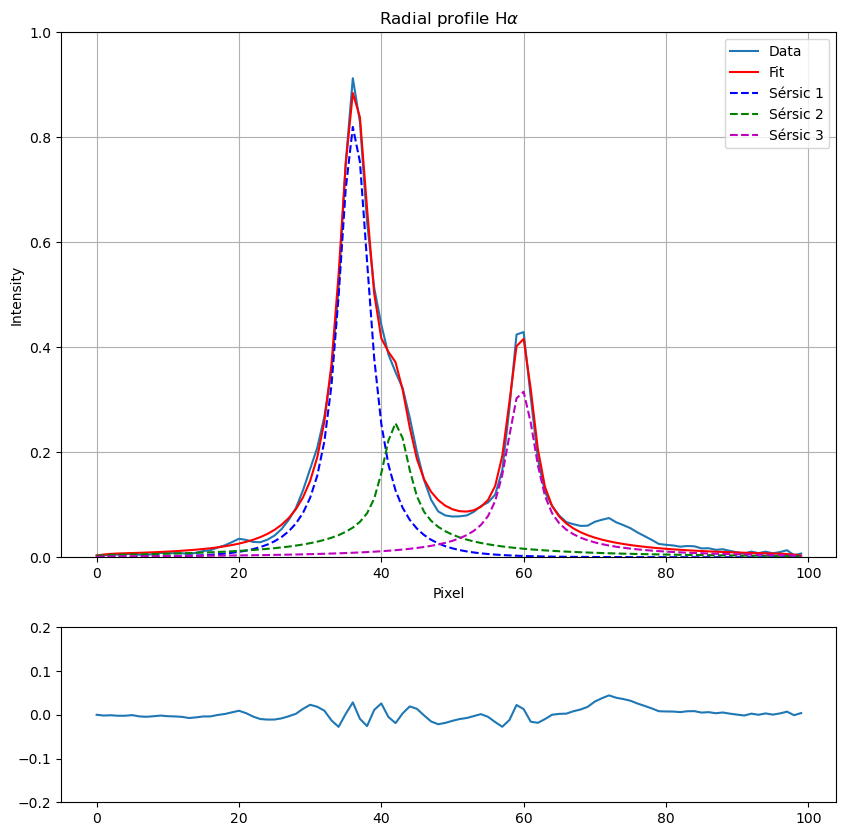

In [21]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[2], chi_quad[2] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params3)
print(aic[2], chi_quad[2])
dof_HA = len(radial_profile_HA) - len(best_params3)
print('Reduced chi square:', chi_quad[2] / dof_HA)
red_chi[2] = chi_quad[2] / dof_HA
plt.savefig('AIC_3')

In [22]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
    
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 2.74859357215222
differential_evolution step 2: f(x)= 0.8301441606888093
differential_evolution step 3: f(x)= 0.8301441606888093
differential_evolution step 4: f(x)= 0.8301441606888093
differential_evolution step 5: f(x)= 0.8301441606888093
differential_evolution step 6: f(x)= 0.8301441606888093
differential_evolution step 7: f(x)= 0.8301441606888093
differential_evolution step 8: f(x)= 0.8301441606888093
differential_evolution step 9: f(x)= 0.8301441606888093
differential_evolution step 10: f(x)= 0.8301441606888093
differential_evolution step 11: f(x)= 0.7101431951250567
differential_evolution step 12: f(x)= 0.6797980288174399
differential_evolution step 13: f(x)= 0.6797980288174399
differential_evolution step 14: f(x)= 0.6797980288174399
differential_evolution step 15: f(x)= 0.6797980288174399
differential_evolution step 16: f(x)= 0.6797980288174399
differential_evolution step 17: f(x)= 0.4520752202559351
differential_evolution step 18: f(x)= 0.45

757.7717086286365 719.2174917611666
Reduced chi square: 8.562112997156746


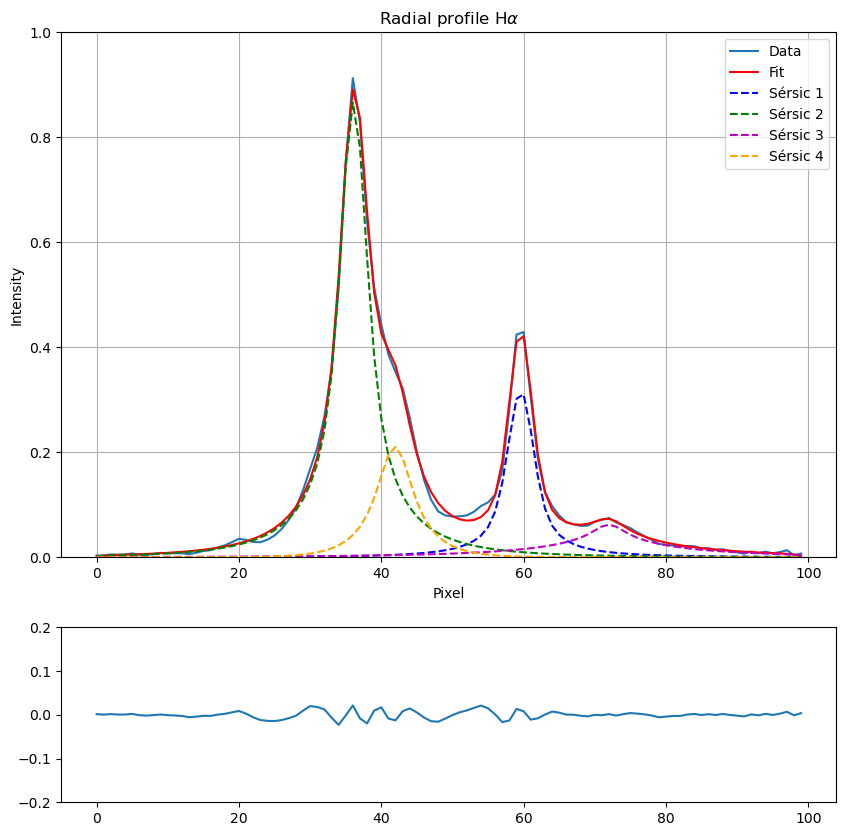

In [23]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[3], chi_quad[3] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params4)
print(aic[3], chi_quad[3])
dof_HA = len(radial_profile_HA) - len(best_params4)
print('Reduced chi square:', chi_quad[3] / dof_HA)
red_chi[3] = chi_quad[3] / dof_HA
plt.savefig('AIC_4')

In [24]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
    
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
    
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 2.935230655663954
differential_evolution step 2: f(x)= 2.217875895237119
differential_evolution step 3: f(x)= 2.217875895237119
differential_evolution step 4: f(x)= 2.217875895237119
differential_evolution step 5: f(x)= 1.8783155409576786
differential_evolution step 6: f(x)= 0.9494963625636724
differential_evolution step 7: f(x)= 0.9494963625636724
differential_evolution step 8: f(x)= 0.9494963625636724
differential_evolution step 9: f(x)= 0.9494963625636724
differential_evolution step 10: f(x)= 0.9494963625636724
differential_evolution step 11: f(x)= 0.9494963625636724
differential_evolution step 12: f(x)= 0.9494963625636724
differential_evolution step 13: f(x)= 0.9494963625636724
differential_evolution step 14: f(x)= 0.733094303853775
differential_evolution step 15: f(x)= 0.733094303853775
differential_evolution step 16: f(x)= 0.733094303853775
differential_evolution step 17: f(x)= 0.733094303853775
differential_evolution step 18: f(x)= 0.73309430

568.7258243523656 518.0929129599606
Reduced chi square: 6.476161411999508


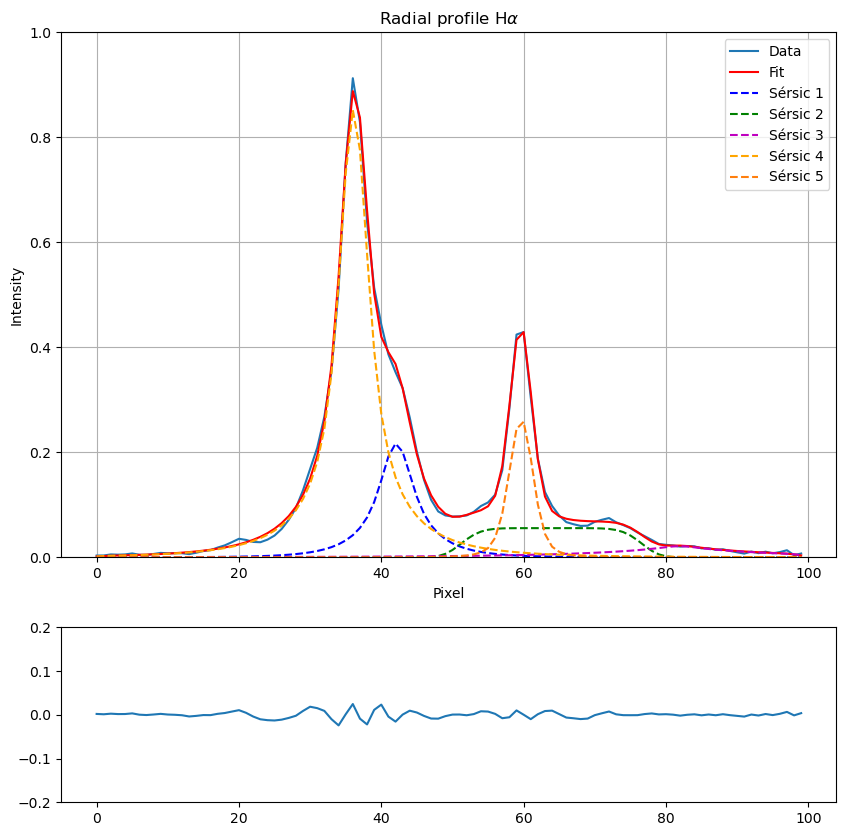

In [25]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[4], chi_quad[4] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params5)
print(aic[4], chi_quad[4])
dof_HA = len(radial_profile_HA) - len(best_params5)
print('Reduced chi square:', chi_quad[4] / dof_HA)
red_chi[4] = chi_quad[4] / dof_HA
plt.savefig('AIC_5')

In [26]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
    
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
    
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 10.629183312070822
differential_evolution step 2: f(x)= 10.629183312070822
differential_evolution step 3: f(x)= 7.945618904070179
differential_evolution step 4: f(x)= 3.5936066979529517
differential_evolution step 5: f(x)= 3.1900407935185275
differential_evolution step 6: f(x)= 3.1900407935185275
differential_evolution step 7: f(x)= 3.1900407935185275
differential_evolution step 8: f(x)= 2.165113665379027
differential_evolution step 9: f(x)= 2.165113665379027
differential_evolution step 10: f(x)= 2.165113665379027
differential_evolution step 11: f(x)= 2.165113665379027
differential_evolution step 12: f(x)= 2.165113665379027
differential_evolution step 13: f(x)= 2.0537170942524483
differential_evolution step 14: f(x)= 0.7112013043355493
differential_evolution step 15: f(x)= 0.7112013043355493
differential_evolution step 16: f(x)= 0.7112013043355493
differential_evolution step 17: f(x)= 0.7112013043355493
differential_evolution step 18: f(x)= 0.711201

512.5955175738259 448.5955175738258
Reduced chi square: 5.902572599655603


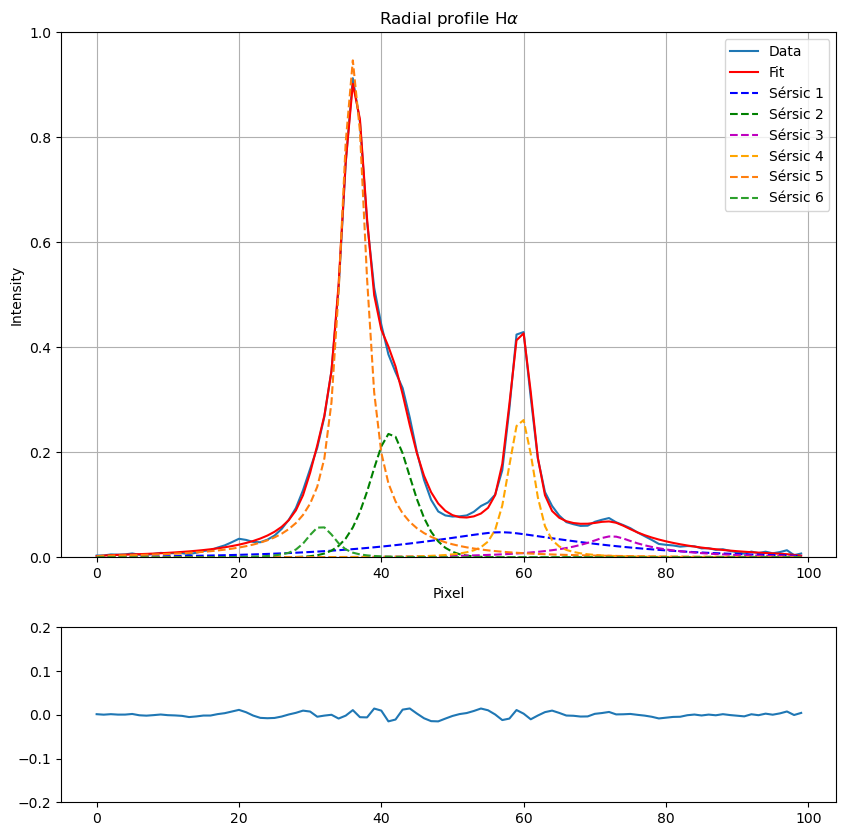

In [27]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

aic[5], chi_quad[5] = AIC(x_axes, radial_profile_HA, radial_profile_error_HA, best_params6)
print(aic[5], chi_quad[5])
dof_HA = len(radial_profile_HA) - len(best_params6)
red_chi[5] = chi_quad[5] / dof_HA
print('Reduced chi square:', chi_quad[5] / dof_HA)
plt.savefig('AIC_6')

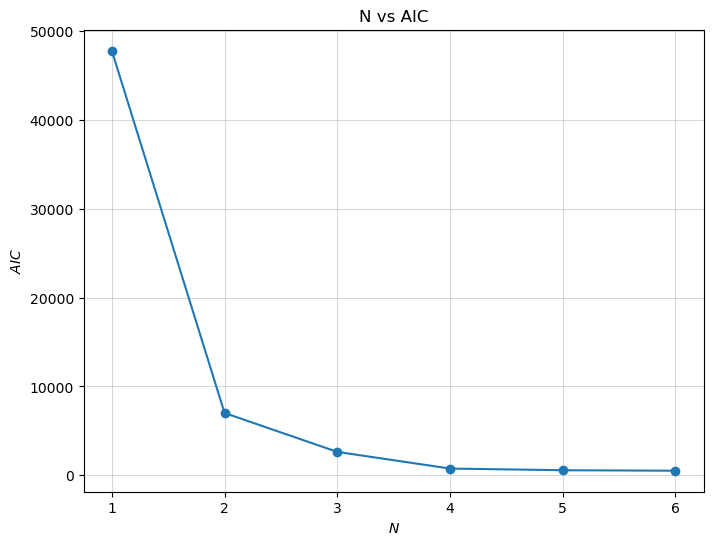

In [28]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('$N$')
ax1.set_ylabel('$AIC$')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)